In [51]:
import numpy as np
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.append(os.path.abspath('..'))
from lib_algebra import QR_dec, QR_eigensolver


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [52]:
plt.rcParams.update({
    "text.usetex": True,           # Attiva l'uso di LaTeX per tutto il testo
    "font.family": "serif",        # Usa un font Serif per il testo normale
    "font.serif": ["Palatino"],    # Specifica Palatino (molto simile a quello in foto)
    "axes.labelsize": 16,          # Dimensione font etichette assi
    "font.size": 14,                # Dimensione font generale
    "legend.fontsize": 14,         # Dimensione font legenda
    "xtick.labelsize": 13,         # Dimensione numeri asse x
    "ytick.labelsize": 13,         # Dimensione numeri asse y
    "figure.figsize": (8, 6),      # Dimensione predefinita della figura
    "figure.dpi": 100,             # Risoluzione
    
    "text.latex.preamble": r"\usepackage{amsmath} \usepackage{amssymb}"
})

Write a function that accepts a matrix $A$, a tolerance $\epsilon$ and the maximal number of iterations $N$, and that returns the eigenvectors and eigenvalues of $A$ from successive applications of the QR decomposition, written before.
Since we expect the resulting matrix $A_{\infty}$ to have eigenvalues distributed along the diagonal, define stopping criterion by demanding that all elements outside the diagonal are compatible with zero, for example, of by demanding that the eigenvalues do not change within a given accuracy, or other similar conditions.

The basic structure of the code is

```Python
function qr_eigen(A, tol, N):
    Ak = copy of A, to leave A untouched
    Qk = identity matrix
    for i up to N:
        Q, R = qr(Ak)
        Ak = R.Q
        Qk = Qk.Q
        if check < tol
            break
    return diagonal of Ak, Qk
```
As a test matrix consider the tridiagonal matrix describing the Laplacian operator in one dimension for modest sizes of $O(10)$. Produce a plot showing the convergence of each individual eigenvalue

In [53]:
ndim = 3
re = np.random.rand(ndim, ndim)
im = np.random.rand(ndim, ndim)
Z = re + 1j * im
A_test = (Z + Z.T.conj()) / 2

# A_test = (mat_rand + mat_rand.T) * 50
# A_test = np.array([[2.,1],[1,3]])




eigval, eigvect = QR_eigensolver(A_test)

print('\nA =\n', A_test)
print('\neig_val =', eigval)
print('\neig_vect =', eigvect)


A =
 [[0.0830456 +0.j         0.36608427+0.25677534j 0.71859713+0.13640986j]
 [0.36608427-0.25677534j 0.05336642+0.j         0.73084615-0.14957098j]
 [0.71859713-0.13640986j 0.73084615+0.14957098j 0.71894393+0.j        ]]

eig_val = [ 1.66399952-2.53905976e-17j -0.48701082+1.56897992e-17j
 -0.32163275-2.16871448e-17j]

eig_vect = [[-0.47548275-2.36843639e-17j -0.00544731+5.17189376e-01j
  -0.38358635-5.99385631e-01j]
 [-0.41891544+2.21505620e-01j -0.56059869+3.38154637e-01j
   0.06933546+5.84823277e-01j]
 [-0.72056511+1.73629440e-01j  0.32642535-4.44198743e-01j
   0.3788334 -5.70785246e-02j]]


K =
 [[ 2. -1.  0.  0.  0.  0.  0.  0.  0.  0.]
 [-1.  2. -1.  0.  0.  0.  0.  0.  0.  0.]
 [ 0. -1.  2. -1.  0.  0.  0.  0.  0.  0.]
 [ 0.  0. -1.  2. -1.  0.  0.  0.  0.  0.]
 [ 0.  0.  0. -1.  2. -1.  0.  0.  0.  0.]
 [ 0.  0.  0.  0. -1.  2. -1.  0.  0.  0.]
 [ 0.  0.  0.  0.  0. -1.  2. -1.  0.  0.]
 [ 0.  0.  0.  0.  0.  0. -1.  2. -1.  0.]
 [ 0.  0.  0.  0.  0.  0.  0. -1.  2. -1.]
 [ 0.  0.  0.  0.  0.  0.  0.  0. -1.  2.]]

Tolerance reached at step 240


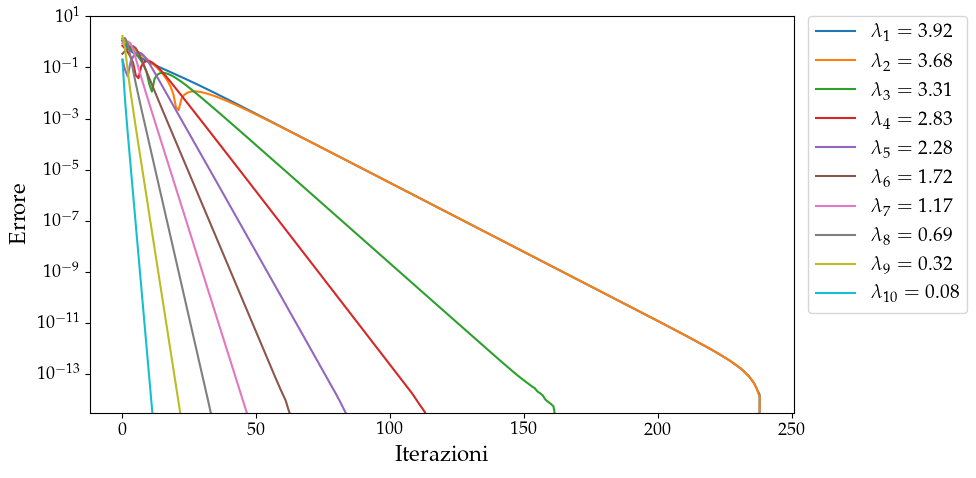

In [54]:
from lib_algebra import tridiagonal


def QR_plot_conv(A_in, tol=1e-14, N_max=int(1e6)):
    Ak = np.copy(A_in)
    n = len(Ak)
    Qk = np.eye(n)
    lamb_arr = []
    
    for i in range(N_max):
        Q, R = QR_dec(Ak)
        Ak_old = np.copy(Ak)
        Ak = R @ Q
        
        eigenVal = np.diag(Ak)
        lamb_arr.append(eigenVal)

        if np.allclose(Ak, Ak_old, rtol=tol):
            print(f'Tolerance reached at step {i+1}')
            return eigenVal, np.array(lamb_arr).T
            
        Qk = Qk @ Q
    eigenVal = np.diag(Ak)
    eigenVect = Qk
    if not np.allclose(A_in @ eigenVect, eigenVal * eigenVect, rtol=tol):
        raise ValueError(f'PROBLEM, solutions don\'t reach the precision in {N_max} steps')
    
    return eigenVal, np.array(lamb_arr).T


K = tridiagonal(10)
print('K =\n', K)
print()

eigval, lamb = QR_plot_conv(K)
errs = abs(lamb - eigval[:, None])

# print('\nLambdas =', eigval)
# print('\nerrs =', errs.T)

xcoo = np.arange(len(lamb[0]))
plt.figure(figsize=(10, 5))
for indice, ele in enumerate(errs):
    plt.plot(xcoo, ele, label=rf'$\lambda_{{{indice+1}}} = {np.real(eigval[indice]):.2f}$')
    plt.xlabel(r'Iterazioni')
    plt.ylabel(r'Errore')
# plt.title('Convergenza dei singoli autovettori')
plt.yscale('log')
plt.ylim(3e-15, 10)
plt.legend()

plt.legend(
    loc='upper left',           # Punto della legenda da ancorare
    bbox_to_anchor=(1.02, 1),    # Coordinate (x, y) dell'ancora rispetto agli assi
    borderaxespad=0,            # Rimuove lo spazio tra l'ancora e la legenda
    frameon=True,               # Mostra il riquadro (come nell'immagine)
    facecolor="#FFFFFF",        # Colore di sfondo grigio chiaro (opzionale)
    fontsize='medium'
)
plt.tight_layout()
plt.savefig('plots/conv_single_eigen.png', dpi=300)
plt.show()

